# 第 8 章 · MLPClassifier 代码实验

[章节网页](../ch8.html)

## 运行内容

- 训练 sklearn MLPClassifier
- 查看预测概率
- 绘制 loss 和网络结构

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备二分类样本：两个输入特征对应一个标签。
X_mlp = np.array([
    [0.12, 0.10],
    [0.20, 0.26],
    [0.28, 0.18],
    [0.36, 0.33],
    [0.64, 0.60],
    [0.72, 0.70],
    [0.82, 0.76],
    [0.92, 0.88],
])
y_mlp = np.array([0, 0, 0, 0, 1, 1, 1, 1])

mlp_df = pd.DataFrame(X_mlp, columns=["特征1", "特征2"])
mlp_df["标签"] = y_mlp
display(mlp_df)

,特征1,特征2,标签
0,0.12,0.10,0
1,0.20,0.26,0
2,0.28,0.18,0
3,0.36,0.33,0
4,0.64,0.60,1
5,0.72,0.70,1
6,0.82,0.76,1
7,0.92,0.88,1


## 1. 训练过程

In [3]:
# 训练 sklearn MLPClassifier，并记录每轮 loss。
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(3,),
        activation="relu",
        solver="sgd",
        learning_rate_init=0.08,
        max_iter=1,
        warm_start=True,
        random_state=2,
    ),
)

loss_rows = []
for epoch in range(1, 41):
    mlp.fit(X_mlp, y_mlp)
    classifier = mlp.named_steps["mlpclassifier"]
    prob = mlp.predict_proba(X_mlp)[:, 1]
    loss_rows.append({
        "轮次": epoch,
        "loss": round(classifier.loss_, 4),
        "平均正类概率": round(float(prob.mean()), 4),
    })

mlp_trace = pd.DataFrame(loss_rows)
display(mlp_trace.tail(8))

,轮次,loss,平均正类概率
32,33,0.4925,0.3402
33,34,0.4821,0.3400
34,35,0.4718,0.3399
35,36,0.4617,0.3399
36,37,0.4518,0.3399
37,38,0.4421,0.3400
38,39,0.4325,0.3402
39,40,0.4232,0.3405


In [4]:
# 查看每个样本的预测概率。
mlp_prob = mlp.predict_proba(X_mlp)[:, 1]
mlp_result = mlp_df.copy()
mlp_result["预测为1的概率"] = np.round(mlp_prob, 3)
mlp_result["预测标签"] = (mlp_prob >= 0.5).astype(int)
display(mlp_result)

,特征1,特征2,标签,预测为1的概率,预测标签
0,0.12,0.10,0,0.088,0
1,0.20,0.26,0,0.138,0
2,0.28,0.18,0,0.166,0
3,0.36,0.33,0,0.247,0
4,0.64,0.60,1,0.521,1
5,0.72,0.70,1,0.521,1
6,0.82,0.76,1,0.521,1
7,0.92,0.88,1,0.521,1


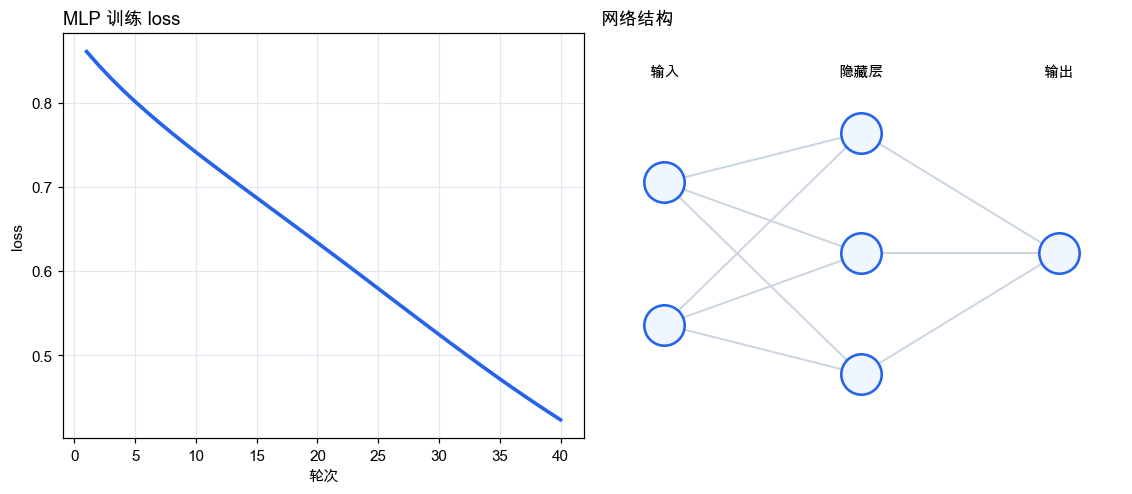

In [5]:
# 绘制 loss 曲线和这个小网络的层级结构。
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6))

axes[0].plot(mlp_trace["轮次"], mlp_trace["loss"], color="#2563eb", linewidth=2.4)
axes[0].set_title("MLP 训练 loss", loc="left", fontweight="bold")
axes[0].set_xlabel("轮次")
axes[0].set_ylabel("loss")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

layer_x = [0, 1.4, 2.8]
layer_y = [[0.8, 1.8], [0.45, 1.3, 2.15], [1.3]]
for i, ys in enumerate(layer_y):
    for y in ys:
        axes[1].scatter(layer_x[i], y, s=700, color="#eff6ff", edgecolor="#2563eb", linewidth=1.7, zorder=3)
for y1 in layer_y[0]:
    for y2 in layer_y[1]:
        axes[1].plot([layer_x[0], layer_x[1]], [y1, y2], color="#cbd5e1", linewidth=1.3, zorder=1)
for y1 in layer_y[1]:
    axes[1].plot([layer_x[1], layer_x[2]], [y1, layer_y[2][0]], color="#cbd5e1", linewidth=1.3, zorder=1)
axes[1].text(0, 2.55, "输入", ha="center", fontweight="bold")
axes[1].text(1.4, 2.55, "隐藏层", ha="center", fontweight="bold")
axes[1].text(2.8, 2.55, "输出", ha="center", fontweight="bold")
axes[1].set_title("网络结构", loc="left", fontweight="bold")
axes[1].set_xlim(-0.45, 3.25)
axes[1].set_ylim(0.0, 2.85)
axes[1].axis("off")

plt.tight_layout()
plt.show()